In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pandas  as pd

In [115]:

df = pd.read_csv('/content/spam (1).csv', encoding='latin-1')

In [116]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [117]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [118]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   target      5572 non-null   object
 1   text        5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [120]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [121]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [122]:
df.duplicated().sum()

np.int64(403)

In [123]:
#remove duplicates
df.drop_duplicates(keep='first',inplace=True)

In [124]:
df.shape

(5169, 2)

# EDA

In [125]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [126]:
df['target'].value_counts()

#data is imbalance

,count
target,
ham,4516
spam,653


([<matplotlib.patches.Wedge at 0x7eea8525ca10>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

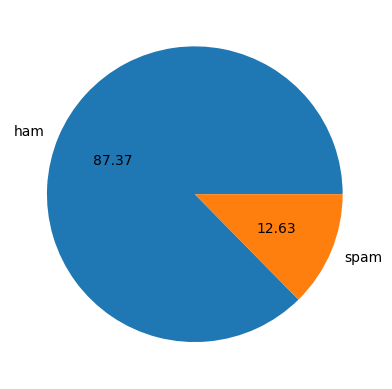

In [127]:
#seeing the percentage through pie chart
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')


In [128]:
#convert the target columns in 0 and 1
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [129]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [130]:
import nltk

In [131]:
!pip install nltk

In [132]:

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [133]:
#creating more features related to the count
df['num_char']=df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [134]:
#no of words
import nltk
nltk.download('punkt_tab')
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [135]:
#no of sentences
df['num_sen']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_char,num_words,num_sen
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [136]:
#understing the spam vs no smap based on char,words,sentences
#not spam

df[df['target'] == 0][['num_char','num_words','num_sen']].describe()


,num_char,num_words,num_sen
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [137]:
#spam
df[df['target'] == 1][['num_char','num_words','num_sen']].describe()

#by just seeing spam emails cchar,wordss,sens lenghts are higher as compared to not spam


,num_char,num_words,num_sen
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_char', ylabel='Count'>

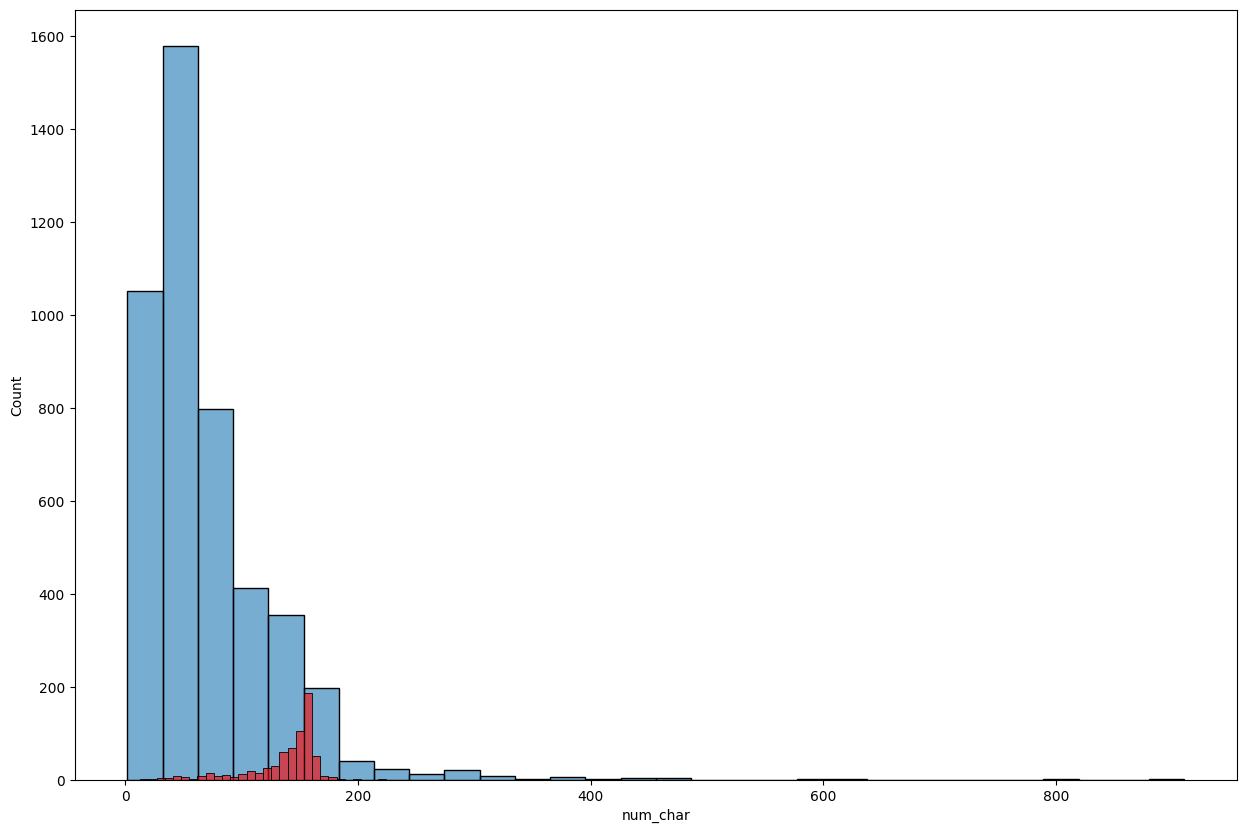

In [138]:
import seaborn as sns
plt.figure(figsize=(15,10))

sns.histplot(df[df['target']==0]['num_char'],bins=30,label='ham',alpha=0.6)
sns.histplot(df[df['target']==1]['num_char'],bins=30,label='spam',alpha=0.6,color='red')


<Axes: xlabel='num_words', ylabel='Count'>

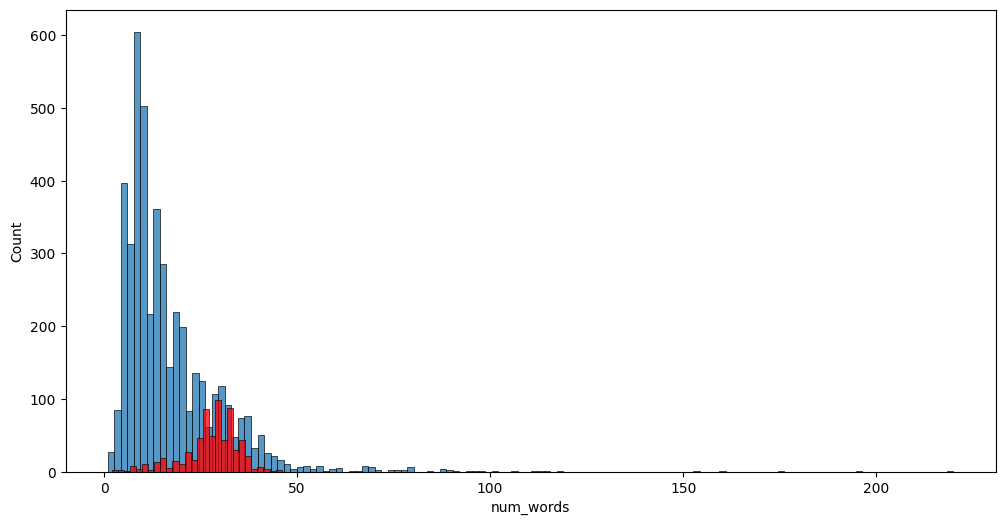

In [139]:

plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

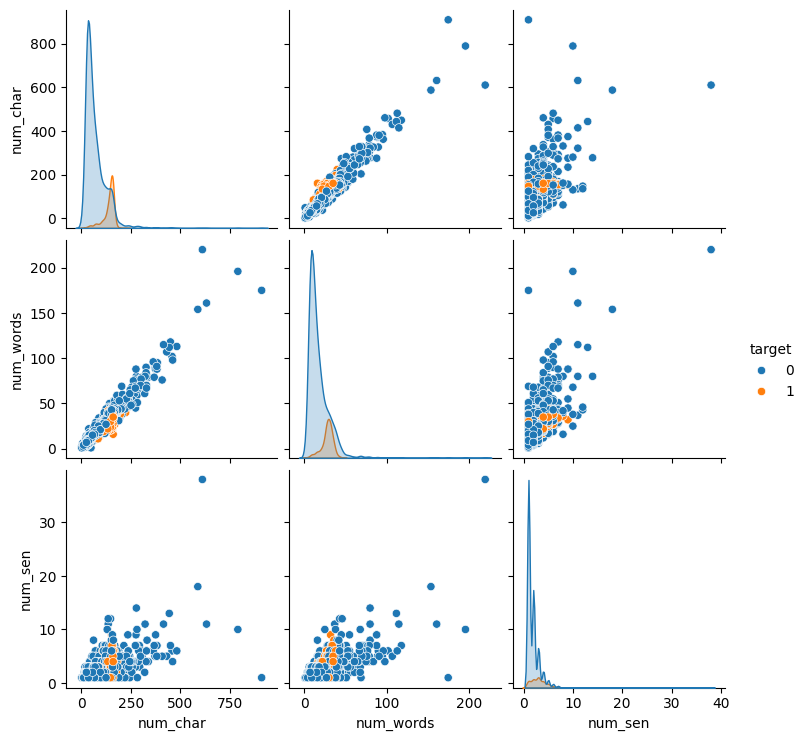

In [140]:
sns.pairplot(df,hue='target')

<Axes: >

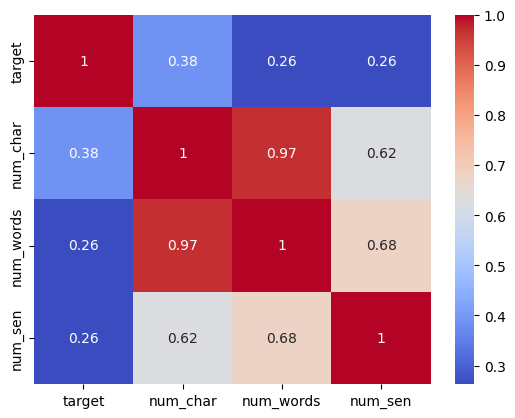

In [141]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
#

In [142]:
#data  preprocessing

# case
#Tokenization
#Removing special characters
#Removing stop words and punctuation
# Stemming

In [143]:
df['text']=df['text'].str.lower()
df.head()

,target,text,num_char,num_words,num_sen
0,0,"go until jurong point, crazy.. available only ...",111,24,2
1,0,ok lar... joking wif u oni...,29,8,2
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,37,2
3,0,u dun say so early hor... u c already then say...,49,13,1
4,0,"nah i don't think he goes to usf, he lives aro...",61,15,1


In [144]:
#removing special charcters
import re
def remove_special(text):
  return re.sub(r'[^a-zA-Z0-9 ]', '', text)
df['text']=df['text'].apply(remove_special)

In [145]:
#removing html tags if present
import re

def remove_html(text):
    return re.sub(r'<.*?>', '', text)
df['text']=df['text'].apply(remove_html)


In [146]:
#remove stop word and puncutations
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # removing stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

df['text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [147]:
#remove stemming
import nltk
from nltk.stem import PorterStemmer
ps=PorterStemmer()
def stem_txt(text):
   words = text.split()
   words = [ps.stem(word) for word in words]
   return " ".join(words)
   df['text'] = df['text'].apply(stem_text)

In [148]:
df.head()

,target,text,num_char,num_words,num_sen
0,0,go jurong point crazy available bugis n great ...,111,24,2
1,0,ok lar joking wif u oni,29,8,2
2,1,free entry 2 wkly comp win fa cup final tkts 2...,155,37,2
3,0,u dun say early hor u c already say,49,13,1
4,0,nah dont think goes usf lives around though,61,15,1


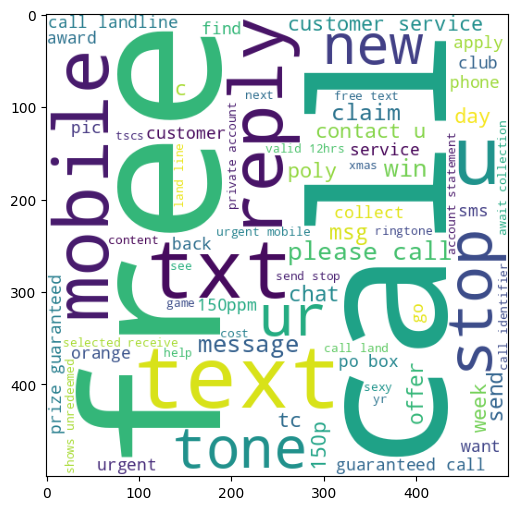

In [149]:
#try to see most frquent words in the text of spam mail
from wordcloud import WordCloud

wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc=wc.generate(df[df['target']==1]['text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)


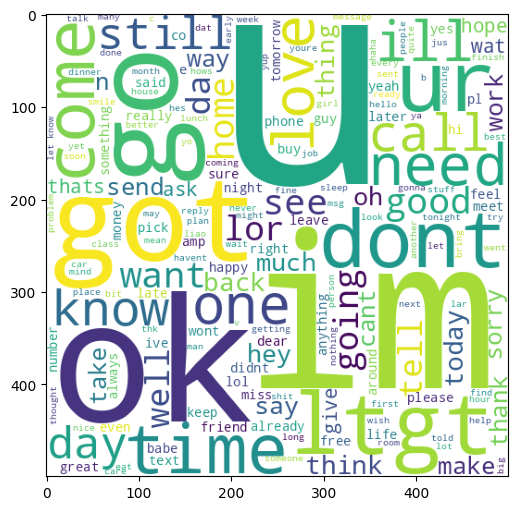

In [150]:
#try to see most frquent words in the text of spam mail
ham_wc=wc.generate(df[df['target']==0]['text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
#

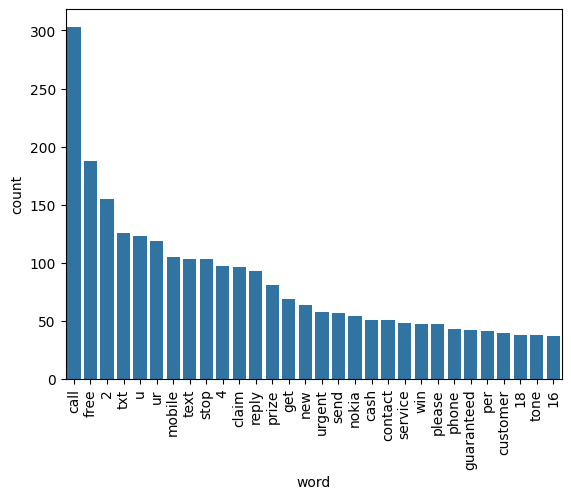

In [151]:
#lets count the word frqueny in  wc
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# create corpus
spam_corpus = []
for msg in df[df['target'] == 1]['text']:
    for word in msg.split():
        spam_corpus.append(word)

# get top 30 words
common_words = Counter(spam_corpus).most_common(30)

# convert to dataframe
df_common = pd.DataFrame(common_words, columns=['word', 'count'])

# plot
sns.barplot(x='word', y='count', data=df_common)
plt.xticks(rotation='vertical')
plt.show()

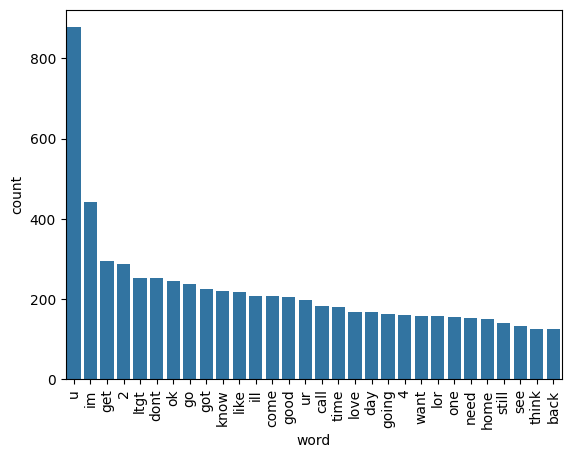

In [152]:
#for non_spam
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# create corpus
spam_corpus = []
for msg in df[df['target'] == 0]['text']:
    for word in msg.split():
        spam_corpus.append(word)

# get top 30 words
common_words = Counter(spam_corpus).most_common(30)

# convert to dataframe
df_common = pd.DataFrame(common_words, columns=['word', 'count'])

# plot
sns.barplot(x='word', y='count', data=df_common)
plt.xticks(rotation='vertical')
plt.show()

# Model **Building**

In [153]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [154]:
X = tfidf.fit_transform(df['text']).toarray()
X.shape

(5169, 3000)

In [155]:
y = df['target'].values

In [156]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score


In [157]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [158]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8820116054158608
[[793 103]
 [ 19 119]]
0.536036036036036


In [159]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[896   0]
 [ 27 111]]
1.0


In [160]:

bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9816247582205029
[[896   0]
 [ 19 119]]
1.0


In [161]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [162]:
svc=SVC(kernel='sigmoid',gamma=0.1)
knc=KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)




In [163]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [164]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [ ]:
accuracy_scores = []
precision_scores = []
for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9264990328820116
Precision -  1.0
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9738878143133463
Precision -  1.0
For  DT
Accuracy -  0.9361702127659575
Precision -  0.8673469387755102
For  LR
Accuracy -  0.9458413926499033
Precision -  0.9183673469387755
For  RF
Accuracy -  0.9709864603481625
Precision -  0.9821428571428571
For  AdaBoost
Accuracy -  0.9274661508704062
Precision -  0.8987341772151899
For  BgC
Accuracy -  0.9642166344294004
Precision -  0.9243697478991597
For  ETC
Accuracy -  0.9738878143133463
Precision -  0.9586776859504132
For  GBDT
Accuracy -  0.9516441005802708
Precision -  0.9313725490196079
For  xgb
Accuracy -  0.9709864603481625
Precision -  0.95


In [ ]:

performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
perfortmance_df

NameError: name 'perfortmance_df' is not defined